# Introduction



This notebook analyzes IT incident data to understand system reliability and incident distribution patterns.

We will use Python (Pandas + Matplotlib) for:
- Data exploration
- Aggregation analysis
- Risk identification
- Visual insights



# Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nalisha/itsm-incident-system-relationship-dataset/incident_systems.csv')

df.head()

,incident_id,system_id
0,I0001,S0016
1,I0002,S0314
2,I0003,S0190
3,I0004,S0497
4,I0005,S0520


# Dataset Overview

In [2]:
df.shape

(500, 2)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   incident_id  500 non-null    object
 1   system_id    500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


# Basic Statistics

In [4]:
total_incidents = df['incident_id'].nunique()
total_systems = df['system_id'].nunique()

total_incidents, total_systems

(500, 343)

In [5]:
system_counts = df.groupby('system_id').size().sort_values(ascending=False)

system_counts.head(10)

system_id
S0500    4
S0268    4
S0372    4
S0174    4
S0231    4
S0031    4
S0460    3
S0398    3
S0432    3
S0386    3
dtype: int64

# Top 10 Most Affected Systems

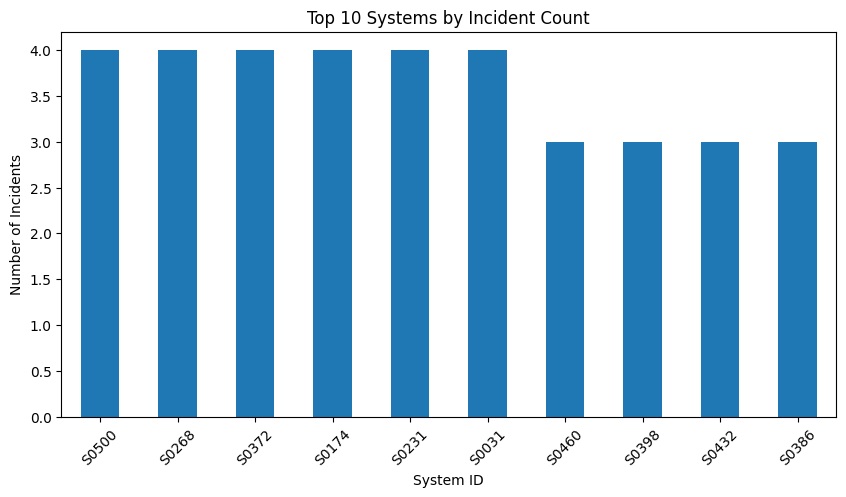

In [6]:
import matplotlib.pyplot as plt

top10 = system_counts.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 Systems by Incident Count')
plt.xlabel('System ID')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()

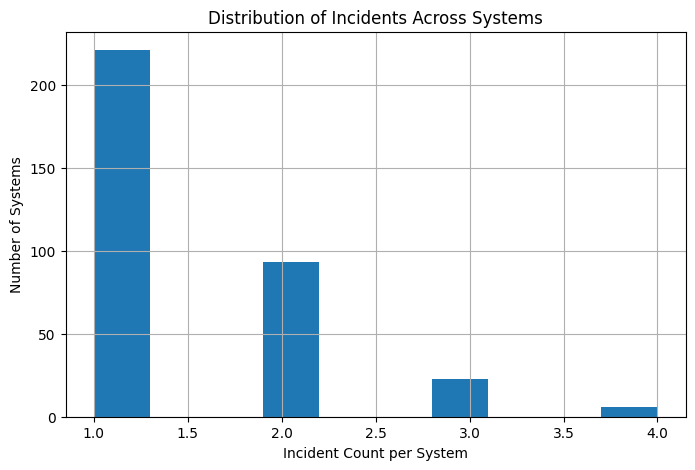

In [7]:
plt.figure(figsize=(8,5))
system_counts.hist(bins=10)
plt.title('Distribution of Incidents Across Systems')
plt.xlabel('Incident Count per System')
plt.ylabel('Number of Systems')
plt.show()

In [8]:
def risk_level(x):
    if x >= 4:
        return "High Risk"
    elif x >= 2:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df = system_counts.reset_index()
risk_df.columns = ['system_id', 'incident_count']

risk_df['risk_level'] = risk_df['incident_count'].apply(risk_level)

risk_df.head()

,system_id,incident_count,risk_level
0,S0500,4,High Risk
1,S0268,4,High Risk
2,S0372,4,High Risk
3,S0174,4,High Risk
4,S0231,4,High Risk


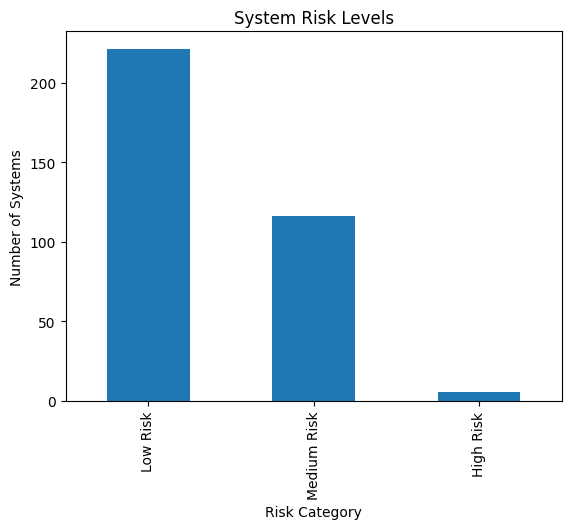

In [9]:
risk_df['risk_level'].value_counts().plot(kind='bar')

plt.title('System Risk Levels')
plt.xlabel('Risk Category')
plt.ylabel('Number of Systems')
plt.show()

## Key Findings

- Total incidents: 500
- Total systems: 343
- Most systems have only 1 incident
- Few systems have repeated incidents (up to 4)
- Small group of systems are High Risk

## Business Insight

Systems with repeated incidents should be monitored for:
- Performance issues
- Infrastructure failures
- Maintenance gaps